# 06 — Qwen2.5-7B Zero-Shot on Full-Concat Scrubbed+ Text


In [1]:
import re
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'Qwen/Qwen2.5-7B-Instruct'
TEXT_COLUMN = 'text_full_concat_scrubbed_plus'
MAX_NEW_TOKENS = 20
BATCH_SIZE = 4
OUTPUT_DIR = 'artifacts/llm_zero_shot_fulltext_scrubbed_plus'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')


Device: cuda
GPU: NVIDIA GeForce RTX 4070


## Scrubbing vocabulary

In [2]:
# Scrubbing vocabulary: countries + region aliases + cultivars + producer context
# Lifted from 04.5 so that 02.1 / 03.1 / 04.1.1 / 06.1 / 07.1 are a fair comparison.
COUNTRY_TERMS = {
    "Ethiopia": ["ethiopia", "ethiopian"],
    "Colombia": ["colombia", "colombian", "columbian"],
    "Panama": ["panama", "panamanian"],
    "Kenya": ["kenya", "kenyan"],
    "Indonesia": ["indonesia", "indonesian"],
    "Guatemala": ["guatemala", "guatemalan"],
    "Costa Rica": ["costa rica", "costa rican", "costarican"],
    "El Salvador": ["el salvador", "salvadoran", "salvadorean", "salvadorian"],
    "Rwanda": ["rwanda", "rwandan"],
    "Brazil": ["brazil", "brazilian"],
    "Honduras": ["honduras", "honduran"],
    "Peru": ["peru", "peruvian"],
    "Taiwan": ["taiwan", "taiwanese"],
    "Papua New Guinea": ["papua new guinea", "papua new guinean"],
    "Nicaragua": ["nicaragua", "nicaraguan"],
    "Burundi": ["burundi", "burundian"],
    "Thailand": ["thailand", "thai"],
    "India": ["india", "indian"],
    "Mexico": ["mexico", "mexican"],
    "Tanzania": ["tanzania", "tanzanian"],
    "Yemen": ["yemen", "yemeni"],
    "Ecuador": ["ecuador", "ecuadorian"],
    "Bolivia": ["bolivia", "bolivian"],
    "Jamaica": ["jamaica", "jamaican"],
    "Uganda": ["uganda", "ugandan"],
    "Dominican Republic": ["dominican republic", "dominican"],
    "Zambia": ["zambia", "zambian"],
    "China": ["china", "chinese"],
    "Vietnam": ["vietnam", "vietnamese"],
    "Philippines": ["philippines", "philippine", "filipino"],
    "Malaysia": ["malaysia", "malaysian"],
    "Laos": ["laos", "laotian"],
    "Zimbabwe": ["zimbabwe", "zimbabwean"],
    "Haiti": ["haiti", "haitian"],
    "Puerto Rico": ["puerto rico", "puerto rican", "puertorican"],
    "Nepal": ["nepal", "nepalese", "nepali"],
    "Myanmar": ["myanmar", "burmese"],
    "Cameroon": ["cameroon", "cameroonian"],
    "Australia": ["australia", "australian"],
    "South Africa": ["south africa", "south african"],
    "Malawi": ["malawi", "malawian"],
    "Venezuela": ["venezuela", "venezuelan", "merida state", "mocoties valley"],
    "Timor-Leste": ["east timor", "timor leste", "timorese"],
    "DR Congo": ["democratic republic of the congo", "dr congo", "congo", "congolese"],
    "United Kingdom": ["united kingdom", "british", "pitcairn island", "saint helena", "st helena", "sandy bay valley"],
    "United States": [
        "usa", "united states", "american",
        "hawaii", "hawai'i", "hawaiian", "hawaii island",
        "big island", "kona", "puna district", "holualoa", "oahu", "maui", "kauai",
        "ka u", "ka'u", "kau",
    ],
}

REGION_ALIASES = {
    "Ethiopia": ["yirgacheffe", "sidamo", "sidama", "guji", "gedeb", "gedeo", "kochere", "hambela",
                 "shakiso", "jimma", "limu", "oromia", "harrar", "kaffa", "bench maji", "bench-maji",
                 "arbegona", "bensa"],
    "Colombia": ["huila", "cauca", "narino", "tolima", "quindio", "caldas", "risaralda", "antioquia",
                 "cundinamarca", "santander", "pitalito", "acevedo", "planadas", "gaitania", "piendamo",
                 "caicedonia", "san agustin", "armenia"],
    "Panama": ["boquete", "chiriqui", "volcan", "jaramillo", "alto quiel", "paso ancho",
               "piedra candela", "canas verdes", "silla del pando", "renacimiento"],
    "Kenya": ["nyeri", "kirinyaga", "kiambu", "embu", "muranga", "murang'a", "thika", "ruiru",
              "mathira", "meru", "nakuru", "gichugu", "karatina"],
    "Indonesia": ["sumatra", "aceh", "gayo", "lintong", "mandheling", "sidikalang", "toraja",
                  "sulawesi", "java", "bali", "kintamani", "flores", "kerinci"],
    "Guatemala": ["huehuetenango", "antigua", "acatenango", "fraijanes", "coban", "atitlan",
                  "chimaltenango", "quiche", "solola", "palencia", "sacatepequez", "san marcos",
                  "hoja blanca", "cuilco"],
    "Costa Rica": ["tarrazu", "central valley", "west valley", "tres rios", "naranjo", "dota",
                   "poas", "alajuela", "brunca", "turrialba", "coto brus", "chirripo"],
    "El Salvador": ["ahuachapan", "chalatenango", "apaneca", "ilamatepec", "santa ana",
                    "el boqueron", "quetzaltepec", "juayua", "ataco"],
    "Rwanda": ["gakenke", "nyamasheke", "karongi", "huye", "nyamagabe", "rulindo", "gikongoro",
               "lake kivu"],
    "Brazil": ["cerrado", "mogiana", "minas gerais", "mantiqueira", "sul de minas",
               "chapada diamantina", "carmo de minas"],
    "Honduras": ["marcala", "copan", "ocotepeque", "comayagua", "intibuca", "santa barbara",
                 "el paraiso", "capucas"],
    "Peru": ["cajamarca", "jaen", "san ignacio", "chanchamayo", "cusco", "villa rica", "oxapampa",
             "junin", "puno"],
    "Taiwan": ["alishan", "yunlin", "chiayi", "chia yi", "nantou", "taichung", "pingtung"],
    "Papua New Guinea": ["wahgi valley", "western highlands", "eastern highlands", "jiwaka",
                         "kainantu", "okapa"],
    "Nicaragua": ["jinotega", "matagalpa", "nueva segovia", "madriz", "ocotal", "dipilto"],
    "Burundi": ["kayanza", "ngozi", "muramvya", "muyinga", "bururi"],
    "Thailand": ["chiang rai", "doi chang", "doi pangkhon", "chiang mai", "nan province"],
    "India": ["coorg", "chikmagalur", "karnataka", "bababudangiri", "nilgiris"],
    "Mexico": ["chiapas", "oaxaca", "veracruz", "coatepec", "pluma hidalgo"],
    "Tanzania": ["mbeya", "ruvuma", "ngorongoro", "arusha", "kilimanjaro", "mbozi"],
    "Yemen": ["haraaz", "haraz", "sanaa", "bani matar", "hayma"],
    "Ecuador": ["loja", "pichincha", "imbabura", "zamora", "chimborazo", "saraguro"],
    "Bolivia": ["caranavi", "yungas", "la paz"],
    "Jamaica": ["blue mountain", "blue mountains"],
    "Uganda": ["rwenzori", "bugisu", "sipi falls"],
    "Vietnam": ["lam dong", "quang tri", "dalat", "cau dat"],
    "Philippines": ["benguet", "bukidnon", "davao"],
    "China": ["yunnan", "baoshan", "puer", "pu'er", "lincong"],
    "Puerto Rico": ["utuado", "yauco", "adjuntas"],
    "Venezuela": ["mocoties valley", "merida state"],
    "Malawi": ["malawi"],
}

REGION_ONLY_TERMS = [
    "central america", "south america", "latin america",
    "east africa", "central africa", "west africa", "africa",
    "asia", "the americas", "americas",
    "central and south america", "south and central america",
    "east and central africa", "various africa growing regions",
]

CULTIVAR_TERMS = [
    "sl28", "sl-28", "sl 28", "sl34", "sl-34", "sl 34",
    "ruiru 11", "ruiru-11", "batian", "k7",
    "gesha", "geisha",
    "pacamara", "pache", "villa sarchi",
    "bourbon", "pink bourbon", "yellow bourbon", "red bourbon",
    "caturra", "catuai", "catuai vermelho", "catuai amarelo",
    "typica", "mundo novo",
    "maragogipe", "maragogype", "maracaturra",
    "castillo", "colombia variety", "variedad colombia", "tabi",
    "heirloom", "ethiopian heirloom",
    "tim tim", "s795", "ateng",
    "catimor", "sarchimor", "icatu", "obata",
]

PRODUCER_CONTEXT_TERMS = [
    "finca", "hacienda", "beneficio",
    "cup of excellence",
    "washing station", "wet mill",
    "best of panama",
]

all_scrub_terms = []
for v in COUNTRY_TERMS.values():    all_scrub_terms.extend(v)
for v in REGION_ALIASES.values():   all_scrub_terms.extend(v)
all_scrub_terms.extend(REGION_ONLY_TERMS)
all_scrub_terms.extend(CULTIVAR_TERMS)
all_scrub_terms.extend(PRODUCER_CONTEXT_TERMS)
all_scrub_terms = sorted(set(all_scrub_terms), key=len, reverse=True)
print(f'Loaded {len(all_scrub_terms)} scrub terms')

SCRUB_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in all_scrub_terms) + r')\b',
    flags=re.IGNORECASE,
)

def scrub(text):
    if not isinstance(text, str) or not text:
        return ''
    return SCRUB_PATTERN.sub(' [ORIGIN] ', text)


Loaded 403 scrub terms


## Build text column

In [3]:
# Concat Blind Assessment + Notes + Who Should Drink It + Bottom Line, then scrub
def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def normalize_text_keep_brackets(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']

def concat_and_scrub(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            raw = minimal_raw_text(v)
            scrubbed = scrub(raw)
            cleaned = normalize_text_keep_brackets(scrubbed)
            pieces.append(cleaned)
    return ' '.join(p for p in pieces if p)

df = pd.read_csv('Data/final_coffee_reviews.csv')
df['text_full_concat_scrubbed_plus'] = df.apply(concat_and_scrub, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['origin_country'] = df['Country'].astype('string').str.strip().replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

# Leakage audit
def contains_own_country(row):
    t = row['text_full_concat_scrubbed_plus'].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False
work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())

print(f'Rows: {len(work)} | Classes: {work["origin_country"].nunique()}')
print(f'Avg scrubbed+ text length (chars): {int(work["text_full_concat_scrubbed_plus"].str.len().mean())}')
print(f'Country-name leakage: {leak_rate:.1%}  (target: <2%)')


Rows: 6820 | Classes: 15
Avg scrubbed+ text length (chars): 875
Country-name leakage: 0.8%  (target: <2%)


## Split; collect the test set

In [4]:
y = work['origin_country']
row_idx = work.index
train_idx, temp_idx, _, y_temp = train_test_split(row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
val_idx, test_idx, _, _ = train_test_split(temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

test_df = work.loc[test_idx].reset_index(drop=True)
label_names = sorted(work['origin_country'].unique())
print(f'Test samples: {len(test_df)}, Classes: {len(label_names)}')


Test samples: 1023, Classes: 15


## Load Qwen2.5-7B-Instruct in 4-bit

In [5]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_CHECKPOINT, quantization_config=bnb_config, device_map='auto',
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'  # REQUIRED for batched decoder-only generation

print('Model loaded.')
print(f'Padding side: {tokenizer.padding_side}')
print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded.
Padding side: left
VRAM used: 5.56 GB


## Prompt design

In [6]:
country_list_str = ', '.join(label_names)

# Same synthetic flavor-only few-shot as in 06 (no geographic terms -> scrub-invariant)
FEW_SHOT_EXAMPLES = [
    {'review': 'bright floral jasmine lemon bergamot in aroma sweetly tart juicy acidity silky mouthfeel', 'country': 'Ethiopia'},
    {'review': 'black currant tomato cedar in aroma and cup wine like acidity full syrupy mouthfeel savory finish', 'country': 'Kenya'},
    {'review': 'earthy herbal cedar tobacco mushroom full heavy body low acidity pungent finish', 'country': 'Indonesia'},
    {'review': 'roasted nuts milk chocolate caramel low acidity smooth medium body sweet finish', 'country': 'Brazil'},
    {'review': 'balanced chocolate caramel almond medium acidity round mouthfeel clean finish', 'country': 'Colombia'},
]

SYSTEM_PROMPT = (
    "You are a coffee-origin classifier. Given a coffee review, reply with the country of origin.\n"
    f"Valid countries (pick exactly one): {country_list_str}.\n"
    "RULES:\n"
    "1. Output ONLY the country name from the list above.\n"
    "2. No explanation, no punctuation, no quotes, no prefix words like 'Answer:' or 'Country:'.\n"
    "3. Exactly one country name on a single line. Nothing else."
)

def build_prompt(review_text):
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]
    for ex in FEW_SHOT_EXAMPLES:
        messages.append({'role': 'user', 'content': f'Review: {ex["review"]}'})
        messages.append({'role': 'assistant', 'content': ex['country']})
    messages.append({'role': 'user', 'content': f'Review: {review_text}'})
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def parse_country(output, valid_labels):
    output = output.strip().lower()
    for label in valid_labels:
        if label.lower() == output: return label
    for label in valid_labels:
        if label.lower() in output: return label
    return 'UNKNOWN'

# Sanity check
for t in ['Ethiopia', 'ethiopia.', 'The origin is Kenya.', 'probably united states', 'nonsense']:
    print(repr(t), '->', parse_country(t, label_names))


'Ethiopia' -> Ethiopia
'ethiopia.' -> Ethiopia
'The origin is Kenya.' -> Kenya
'probably united states' -> United States
'nonsense' -> UNKNOWN


## Run zero-shot inference on the test set

In [7]:
test_texts = test_df[TEXT_COLUMN].tolist()
test_labels = test_df['origin_country'].tolist()
prompts = [build_prompt(t) for t in test_texts]

raw_outputs = []
predicted_labels = []
start = time.time()

for batch_start in range(0, len(prompts), BATCH_SIZE):
    batch = prompts[batch_start:batch_start+BATCH_SIZE]
    inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=1024).to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
            temperature=None, top_p=None, pad_token_id=tokenizer.pad_token_id,
        )
    input_len = inputs['input_ids'].shape[1]
    for i, out in enumerate(outputs):
        gen = tokenizer.decode(out[input_len:], skip_special_tokens=True)
        raw_outputs.append(gen)
        predicted_labels.append(parse_country(gen, label_names))
    if (batch_start // BATCH_SIZE) % 10 == 0:
        elapsed = time.time() - start
        done = batch_start + len(batch)
        eta = elapsed / max(done, 1) * (len(prompts) - done)
        print(f'  {done}/{len(prompts)} | elapsed {elapsed:.0f}s | ETA {eta:.0f}s')

print(f'\nTotal inference time: {time.time()-start:.0f}s')
print(f'UNKNOWN predictions: {predicted_labels.count("UNKNOWN")} / {len(predicted_labels)}')


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  4/1023 | elapsed 3s | ETA 868s
  44/1023 | elapsed 15s | ETA 339s
  84/1023 | elapsed 26s | ETA 293s
  124/1023 | elapsed 37s | ETA 269s
  164/1023 | elapsed 48s | ETA 252s
  204/1023 | elapsed 59s | ETA 237s
  244/1023 | elapsed 70s | ETA 224s
  284/1023 | elapsed 81s | ETA 211s
  324/1023 | elapsed 92s | ETA 199s
  364/1023 | elapsed 103s | ETA 187s
  404/1023 | elapsed 114s | ETA 175s
  444/1023 | elapsed 125s | ETA 164s
  484/1023 | elapsed 136s | ETA 152s
  524/1023 | elapsed 147s | ETA 140s
  564/1023 | elapsed 158s | ETA 129s
  604/1023 | elapsed 169s | ETA 117s
  644/1023 | elapsed 180s | ETA 106s
  684/1023 | elapsed 191s | ETA 95s
  724/1023 | elapsed 203s | ETA 84s
  764/1023 | elapsed 216s | ETA 73s
  804/1023 | elapsed 229s | ETA 63s
  844/1023 | elapsed 243s | ETA 52s
  884/1023 | elapsed 256s | ETA 40s
  924/1023 | elapsed 270s | ETA 29s
  964/1023 | elapsed 283s | ETA 17s
  1004/1023 | elapsed 297s | ETA 6s

Total inference time: 303s
UNKNOWN predictions: 52 / 1023


## Evaluate

=== Qwen2.5-7B Zero-Shot on Scrubbed+ Full-Concat Text ===
Accuracy:          0.2522
Balanced Accuracy: 0.1602
Macro Precision:   0.3275
Macro Recall:      0.1502
Macro-F1:          0.1703

--- vs 06 (Blind Assessment only, no scrubbing): Macro-F1 0.0646 ---
If 06.1 drops: scrubbing actually hurt (the extra columns gave more signal to name-drop).
If 06.1 rises: the extra text helps even with country/cultivar words removed.

               precision    recall  f1-score   support

     Ethiopia      0.442     0.398     0.419       299
     Colombia      0.257     0.311     0.281       148
        Kenya      0.857     0.114     0.202       105
    Guatemala      0.118     0.155     0.134        84
    Indonesia      0.647     0.485     0.555        68
   Costa Rica      0.056     0.250     0.092        56
       Panama      0.212     0.132     0.163        53
United States      0.000     0.000     0.000        45
  El Salvador      0.000     0.000     0.000        36
       Brazil      0.

g:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


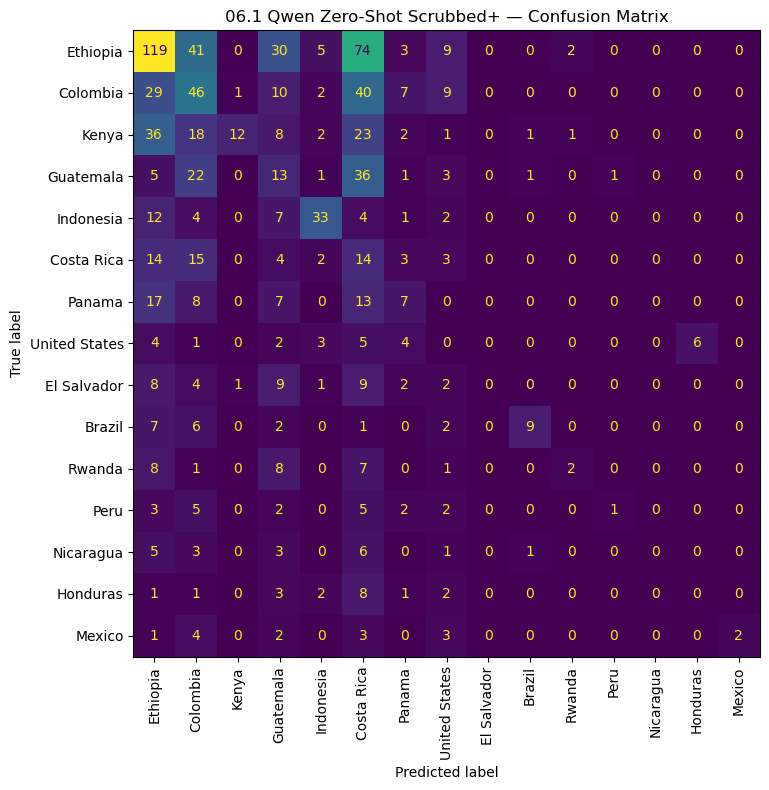

In [8]:
acc = accuracy_score(test_labels, predicted_labels)
bal_acc = balanced_accuracy_score(test_labels, predicted_labels)
prec, rec, f1, _ = precision_recall_fscore_support(test_labels, predicted_labels, average='macro', zero_division=0)

print('=== Qwen2.5-7B Zero-Shot on Scrubbed+ Full-Concat Text ===')
print(f'Accuracy:          {acc:.4f}')
print(f'Balanced Accuracy: {bal_acc:.4f}')
print(f'Macro Precision:   {prec:.4f}')
print(f'Macro Recall:      {rec:.4f}')
print(f'Macro-F1:          {f1:.4f}')
print()
print('--- vs 06 (Blind Assessment only, no scrubbing): Macro-F1 0.0646 ---')
print('If 06.1 drops: scrubbing actually hurt (the extra columns gave more signal to name-drop).')
print('If 06.1 rises: the extra text helps even with country/cultivar words removed.')

class_order = work['origin_country'].value_counts().index.tolist()
print()
print(classification_report(test_labels, predicted_labels, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(test_labels, predicted_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('06.1 Qwen Zero-Shot Scrubbed+ — Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [9]:
results = {
    'notebook': '06.1_LLM_FullText_Scrubbed_Plus',
    'model': MODEL_CHECKPOINT,
    'method': 'zero-shot-5shot',
    'text_column': TEXT_COLUMN,
    'text_columns_used': EXTRA_TEXT_COLS,
    'scrub_tiers': ['countries_and_adjectivals', 'coffee_region_aliases', 'cultivars', 'producer_context_terms'],
    'num_scrub_terms': len(all_scrub_terms),
    'post_scrub_leakage_rate': leak_rate,
    'accuracy': acc, 'balanced_accuracy': bal_acc,
    'macro_precision': prec, 'macro_recall': rec, 'macro_f1': f1,
    'n_unknown': predicted_labels.count('UNKNOWN'), 'n_test': len(test_labels),
}
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2, default=float)

pd.DataFrame({
    'text': test_texts, 'true': test_labels,
    'pred': predicted_labels, 'raw_output': raw_outputs,
}).to_csv(os.path.join(OUTPUT_DIR, 'predictions.csv'), index=False)
print('Saved.')


Saved.
